# NARR-to-PRISM Downscaling: Model Inference

This notebook demonstrates how to run inference with a fine-tuned NARR-to-PRISM downscaling model.

We show how to:
1. Load a trained checkpoint
2. Run predictions over the configured inference date range
3. Denormalize outputs to physical units
4. Write results to NetCDF
5. Visualize sample predictions

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
import sys
from pathlib import Path

# Set REPO_ROOT to the granite-wxc repository root
REPO_ROOT = Path(".").resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NARR_PRISM_DIR = REPO_ROOT / "examples" / "NARR_PRISM"
if str(NARR_PRISM_DIR) not in sys.path:
    sys.path.insert(0, str(NARR_PRISM_DIR))

os.chdir(REPO_ROOT)
print(f"Repository root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Repository root: /data/granite-wxc
Working directory: /data/granite-wxc


In [2]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [3]:
!pip install -q h5netcdf matplotlib xarray scipy torch tqdm pyyaml

In [4]:
# Install granitewxc in editable mode from the repo source
!pip install -q -e {REPO_ROOT}

In [5]:
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action="ignore", category=FutureWarning)

---

## Device Configuration

In [6]:
# ===================== HARDWARE CONFIGURATION (EDIT ME) =====================
# GPUs 2 and 3 are busy with training; use idle GPUs 0 and 1 for parallel date shards.
force_visible_devices = "0,1"  # comma-separated physical GPU ids, or None for all
device_target = "cuda"          # "cuda" or "cpu"
# ============================================================================

if force_visible_devices is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)

import torch
import numpy as np

if device_target == "cuda" and not torch.cuda.is_available():
    print("CUDA not available, falling back to CPU")
    device_target = "cpu"

device = torch.device(device_target)
print(f"Device: {device}")
if device.type == "cuda":
    n_gpu = torch.cuda.device_count()
    print(f"Visible GPUs (CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', 'all')}): {n_gpu}")
    for i in range(n_gpu):
        print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")


Device: cuda
Visible GPUs (CUDA_VISIBLE_DEVICES=0,1): 2
  cuda:0 -> NVIDIA A100 80GB PCIe
  cuda:1 -> NVIDIA A100 80GB PCIe


---

## Configuration

Load the NARR_PRISM YAML configuration and specify the checkpoint to use.

In [7]:
from granitewxc.utils.config import get_config
from narr_prism_utils import case_output_dir, get_case_name, load_yaml, resolve_path

# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = NARR_PRISM_DIR / "NARR_PRISM_subdomain.yaml"  # Must match the YAML used for training
CHECKPOINT_PATH = None   # Set to explicit path, or None for auto-detection
OUTPUT_DIR = None        # Set to override output directory, or None for YAML default
BATCH_SIZE = 8           # Tiles per forward pass per worker GPU
PARALLEL_GPUS = "0,1"    # Physical GPU ids; set None to run in this notebook kernel
# ====================================================================

config_path = str(CONFIG_PATH.resolve())
cfg = load_yaml(config_path)
config = get_config(config_path)
case_name = get_case_name(cfg)

print(f"Config: {config_path}")
print(f"Case name: {case_name}")
print(f"Target variables: {cfg['data']['target_variables']}")
print(f"Inference dates: {cfg['dates']['inference']['start']} to {cfg['dates']['inference']['end']}")
print(f"Parallel GPUs: {PARALLEL_GPUS}")


Config: /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_subdomain.yaml
Case name: narr_prism_California
Target variables: ['ppt', 'tmax', 'tmin']
Inference dates: 2016-01-01 to 2025-12-31
Parallel GPUs: 0,1


---

## Locate Checkpoint

Find the trained model checkpoint. The search order is:
1. Explicit `CHECKPOINT_PATH` (if set above)
2. `inference.checkpoint_path` from the YAML
3. `best.ckpt` or `last.ckpt` under the experiment directory

In [8]:
from importlib import reload
from pathlib import Path
import narr_prism_inference as npi

# Reload to pick up the latest checkpoint-search fixes if this notebook
# has already imported narr_prism_inference in the current kernel session.
npi = reload(npi)

checkpoint_path = npi._find_checkpoint(cfg, CHECKPOINT_PATH)
checkpoint_path = str(Path(checkpoint_path).resolve())
print(f"Using checkpoint: {checkpoint_path}")

Using checkpoint: /data/granite-wxc/examples/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt


---

## Load Model

Recreate the model architecture and load the trained weights.

In [9]:
print("Model loading is handled inside run_inference so the notebook does not keep a duplicate GPU copy alive.")

Model loading is handled inside run_inference so the notebook does not keep a duplicate GPU copy alive.


---

## Run Inference

Execute inference over the date range defined in the YAML configuration.
The output is denormalized to physical units and written to a NetCDF file.

In [10]:
from importlib import reload
import narr_prism_inference as npi

npi = reload(npi)

output_root = OUTPUT_DIR or resolve_path(
    cfg.get("inference", {}).get(
        "output_dir", "./examples/NARR_PRISM/experiments/inference_output"
    )
)
output_dir = str(case_output_dir(output_root, case_name))

if PARALLEL_GPUS:
    gpu_ids = [gpu.strip() for gpu in str(PARALLEL_GPUS).split(",") if gpu.strip()]
    output_path = npi.run_parallel_inference(
        config_path=config_path,
        checkpoint_path=checkpoint_path,
        output_dir=output_dir,
        gpu_ids=gpu_ids,
        batch_size=BATCH_SIZE,
        device=device_target,
    )
else:
    output_path = npi.run_inference(
        config_path=config_path,
        cfg=cfg,
        config=config,
        checkpoint_path=checkpoint_path,
        output_dir=output_dir,
        device=device,
        batch_size=BATCH_SIZE,
    )

print(f"\nInference output saved to: {output_path}")


[inference] Using case_name: narr_prism_California
[inference] Using preprocessing directory: /data/granite-wxc/examples/NARR_PRISM/preprocessed/narr_prism_California
[inference] Using scalar directory: /data/granite-wxc/examples/NARR_PRISM/preprocessed/narr_prism_California/scalars
[dataset] strict preprocessed source: /data/granite-wxc/examples/NARR_PRISM/preprocessed/narr_prism_California/inference (3653 required daily products; raw fallback disabled)
[dataset] canonical PRISM grid fingerprint=f062e76bd115
[parallel] launching 2 inference workers over GPUs 0,1 for 3653 dates -> /data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/narr_prism_California
[parallel] worker 0: GPU 0, log: /data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/narr_prism_California/parallel_worker_0_gpu0.log, command: /home/azureuser/miniforge3/envs/Prithvi/bin/python /data/granite-wxc/examples/NARR_PRISM/narr_prism_inference.py --config /data/granite-wxc/examples/NARR_PRISM/NARR

NARR-PRISM inference (days):   0%|          | 0/3653 [00:00<?, ?day/s]

[parallel] all workers finished -> /data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/narr_prism_California

Inference output saved to: /data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/narr_prism_California


---

## Visualize Results

Load the output NetCDF and plot sample predictions for each target variable.

In [11]:
from pathlib import Path
import xarray as xr

output_path = Path(output_path)
nc_files = sorted(output_path.glob(f"{case_name}_inference_*.nc"))
if not nc_files:
    raise FileNotFoundError(f"No daily inference NetCDF files found in {output_path}")

try:
    # Preferred path when dask is available: keep the daily files lazily combined.
    ds = xr.open_mfdataset([str(p) for p in nc_files], combine="by_coords")
except (ImportError, ValueError) as exc:
    if len(nc_files) <= 512:
        # Dependency-light fallback for small inference runs.
        daily = [xr.open_dataset(str(p)) for p in nc_files]
        ds = xr.concat(daily, dim="time")
    else:
        print(
            "Install dask to lazily open all daily files with xr.open_mfdataset; "
            "showing the first daily file for inspection."
        )
        print(f"open_mfdataset error: {exc}")
        ds = xr.open_dataset(str(nc_files[0]))

print(f"Daily files: {len(nc_files)}")
print(ds)
print(f"\nTime steps available: {len(nc_files)}")
print(f"Time steps opened in ds: {ds.sizes.get('time', 'n/a')}")
print(f"Spatial grid: {ds.sizes.get('lat', 'n/a')} x {ds.sizes.get('lon', 'n/a')}")

Install dask to lazily open all daily files with xr.open_mfdataset; showing the first daily file for inspection.
open_mfdataset error: chunk manager 'dask' is not available. Please make sure 'dask' is installed and importable.
Daily files: 3653
<xarray.Dataset> Size: 13MB
Dimensions:  (time: 1, lat: 1024, lon: 1024)
Coordinates:
  * time     (time) datetime64[ns] 8B 2016-01-01
  * lat      (lat) float64 8kB 32.55 32.56 32.57 32.58 ... 41.06 41.07 41.08
  * lon      (lon) float64 8kB -124.5 -124.4 -124.4 ... -115.9 -115.9 -115.9
Data variables:
    ppt      (time, lat, lon) float32 4MB ...
    tmax     (time, lat, lon) float32 4MB ...
    tmin     (time, lat, lon) float32 4MB ...
Attributes:
    description:             NARR-to-PRISM downscaling inference output
    case_name:               narr_prism_California
    prism_grid_fingerprint:  f062e76bd115320b3e022519d1eb12b9c80a664bdac7c4e3...
    checkpoint:              /data/granite-wxc/examples/NARR_PRISM/experiment...
    inference_s

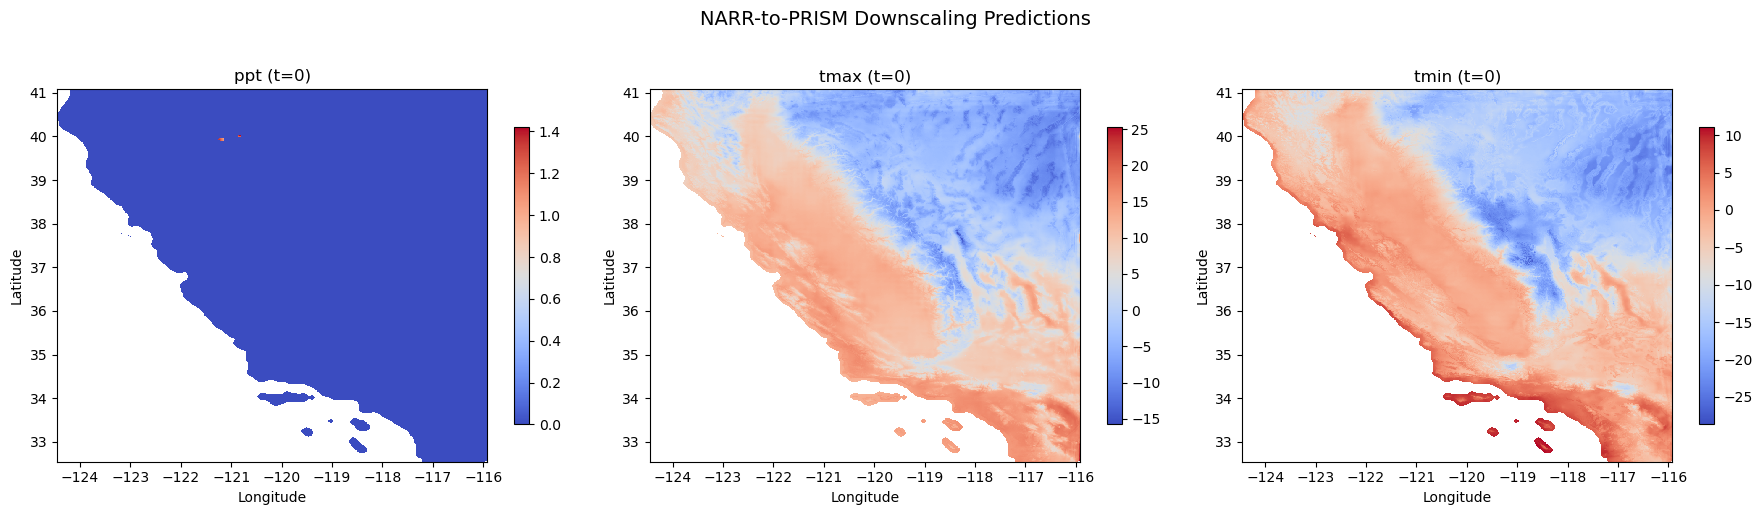

In [12]:
import matplotlib.pyplot as plt

target_variables = cfg["data"]["target_variables"]
n_vars = len(target_variables)

fig, axes = plt.subplots(1, n_vars, figsize=(6 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

# Plot the first time step for each variable
for ax, var in zip(axes, target_variables):
    data = ds[var].isel(time=0)
    im = ax.pcolormesh(ds.lon, ds.lat, data.values, shading="auto", cmap="coolwarm")
    ax.set_title(f"{var} (t=0)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("NARR-to-PRISM Downscaling Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
ds.close()
print("Done.")

Done.


---

## Summary

The inference pipeline:
1. Loaded the trained checkpoint from the case-specific checkpoint directory
2. Ran predictions over the inference date range
3. Wrote physical-unit outputs with proper coordinates and metadata
4. Saved daily NetCDF files under the case-specific inference output directory

Output file location:
```
examples/NARR_PRISM/experiments/inference_output/<case_name>/
```
